# Brain Decoding Multivariate (BDM) Analysis

## Part of the open_dvm Toolbox

Brain Decoding Multivariate (BDM) analysis uses machine learning to predict experimental variables (e.g., stimulus properties) from EEG brain activity patterns. This reveals whether and when the brain encodes behaviorally relevant information.

## Learning Objectives

After completing this tutorial, you will:

- **Run multivariate decoding analysis** — Train and cross-validate a classifier on EEG patterns
- **Interpret decoding results and timing** — Read AUC timecourses and identify when information is present
- **Optimize preprocessing for decoding** — Balance trial averaging against sample size
- **Test generalization across tasks** — Train on one task, test on another without retraining

**Prerequisites:** This tutorial requires preprocessed EEG data (see `01_preprocessing.ipynb`).

## Overview

### Key Concepts
- **Decoding**: Can a classifier learn to predict stimulus properties from brain activity?
- **Temporal Dynamics**: When is the stimulus information available in the EEG signal?
- **Generalization**: Does the decoding model work across different tasks or conditions?

### Key Steps
1. **Basic decoding**: Localizer task (subjects tracked repeated distractor images)
2. **Task decoding**: Main task (search for unique shape; distractor image as distractor)
3. **Trial averaging**: Trade-off between noise reduction and sample size
4. **Cross-task decoding**: Does distractor image representation transfer across tasks?

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import BDM
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_bdm_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Load Preprocessed Data with Eye-Tracking Quality Control

In [2]:
# Download (if not already cached) and locate the preprocessed tutorial
# dataset -- a fast-path that skips running 01_preprocessing.ipynb yourself
from open_dvm.support.datasets import fetch_processed_data

project_folder = fetch_processed_data()
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,        # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),      # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,          # Threshold: 1 degree visual angle
    'viewing_dist': 70,         # Viewing distance (cm)
    'screen_res': (1920, 1080), # Screen resolution (pixels)
    'screen_h': 29,             # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj=sj,                       # subject ID
    fname='ses_01_main',         # preprocessed file name (sub_<sj>_ses_01_main-epo.fif)
    preproc_name='main',         # preprocessing pipeline name (locates parameter files)
    eye_dict=eye_dict            # eye-tracking exclusion criteria
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')
print(f'\nBehavioral data columns:')
print(df.columns.tolist())

Reading /Users/dvm/open_dvm_data/eeg/processed/sub_02_ses_01_main-epo.fif ...


    Found the data of interest:


        t =    -699.22 ...    1000.00 ms


        0 CTF compensation matrices available


Adding metadata with 20 columns


2902 matching events found


No baseline correction applied


0 projection items activated


Eye channel is not specified in eyedict, using HEOG as default


6 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 2 data loaded
  • 2144 trials
  • 39 channels
  • Sampling rate: 512.0 Hz

Behavioral data columns:
['index', 'nr_trials', 'display_trigger', 'RT', 'subject_nr', 'block_cnt', 'block_type', 'correct', 'img_loc', 'target_loc', 'dist_cnd', 'dist_img', 'neut_shape', 'target_cnd', 'high_prob_dist', 'prev_target_loc', 'prev_img_loc', 'target_at_high_prob_loc', 'img_at_high_prob_loc', 'target_presence', 'distractor_presence']


### 1.3 Explore the Behavioral Data Structure

In [3]:
# Explore the data structure
print("Block types available:", df['block_type'].unique())
print("\nLocalizer block - images:")
print(df[df['block_type'] == 'localizer']['dist_img'].value_counts().sort_index())
print("\nMain block - images:")
print(df[df['block_type'] == 'main']['dist_img'].value_counts().sort_index())

Block types available: <StringArray>
['localizer', 'main']
Length: 2, dtype: str

Localizer block - images:
dist_img
0    118
1    131
2    117
3    132
Name: count, dtype: int64

Main block - images:
dist_img
0    407
1    407
2    407
3    425
Name: count, dtype: int64


---

## Section 2: Localizer Task Decoding

The localizer task is specifically designed for decoding analysis - subjects tracked whether a distractor image repeated, creating a simple, high-signal task.

**Question**: Can we decode which distractor image was presented from EEG activity in the localizer task?

**Setup**:
- Decoder: Linear Discriminant Analysis (LDA)
- K-fold cross-validation: 10 folds
- Time window: 0-500 ms post-stimulus
- Metric: Area Under Curve (AUC)
- Variable decoded: Distractor image identity

In [4]:
# Initialize BDM for localizer decoding
bdm_localizer = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',    # Decode image identity
    baseline=(-0.2, 0),      # Baseline correction: -200 to 0 ms
    nr_folds=10,             # 10-fold cross-validation
    elec_oi='all',           # Use all electrodes
    data_type='broadband',   # Time domain (not TF)
    downsample=128           # Downsample to 128 Hz (reduce computational load)
)

print(f"✓ BDM initialized")
print(f"  • Classifier: Linear Discriminant Analysis (LDA)")
print(f"  • Decoding: dist_img (image identity)")
print(f"  • Electrodes: {epochs.info['nchan']} channels")
print(f"  • K-fold: 10 folds")

✓ BDM initialized
  • Classifier: Linear Discriminant Analysis (LDA)
  • Decoding: dist_img (image identity)
  • Electrodes: 39 channels
  • K-fold: 10 folds


In [5]:
# Run decoding on localizer task
output_localizer, _ = bdm_localizer.classify(
    cnds=dict(block_type=['localizer']),  # Select localizer trials
    window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
    labels_oi='all',                      # Use all distractor images
    GAT=False,                            # Standard within-time decoding
    excl_factor=dict(img_loc=[8])         # Exclude trials where image not shown
)

print("✓ Localizer decoding complete")
print(f"  • Conditions: {list(output_localizer.keys())[:-1]}")
print(f"  • Time points: {output_localizer['info']['times'].shape}")

Automatically excluding block_type=['main'] (not specified in cnds parameter)


Dropped 1646 trials after specifying excl_factor
Applying baseline correction (mode: mean)


downsampling data



You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

Fold 2 out of 10 folds in run 1

...

Fold 7 out of 10 folds in run 1

Fold 8 out of 10 folds in run 1

Fold 9 out of 10 folds in run 1

Fold 10 out of 10 folds in run 1

✓ Localizer decoding complete
  • Conditions: ['localizer', 'bdm_info']
  • Time points: (90,)


Times converted from seconds to milliseconds


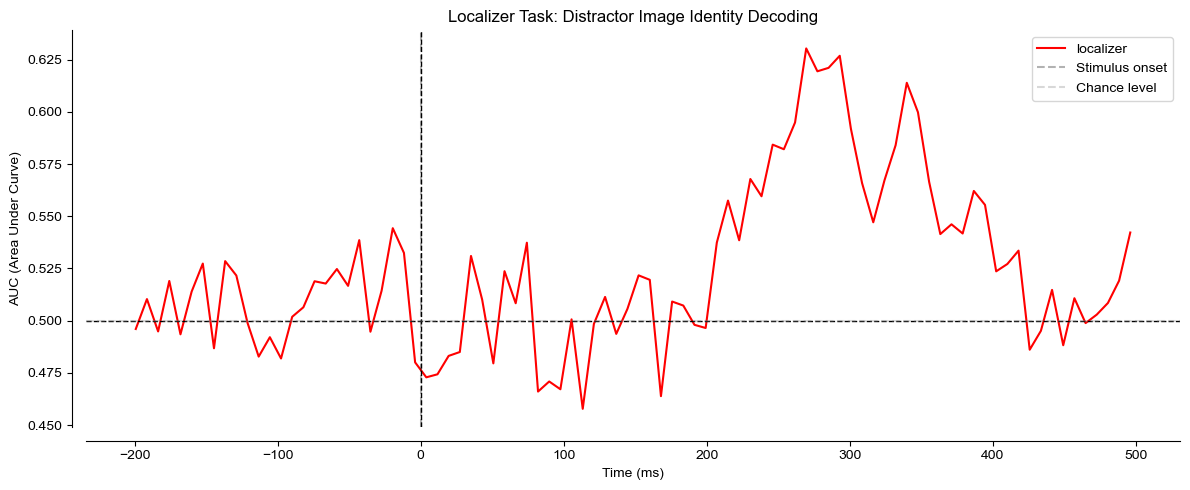


Localizer Decoding Results:
  • Peak AUC: 0.630 at 0.270 s
  • Chance level: 0.500
  • Performance: 13.0% above chance


In [6]:
# Visualize localizer decoding results
fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    output_localizer,
    colors='red',    # Single condition
    stats=False      # Single subject -- no group-level test to run
)
plt.title('Localizer Task: Distractor Image Identity Decoding')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, label='Stimulus onset')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance level')
plt.ylabel('AUC (Area Under Curve)')
plt.legend()
plt.tight_layout()
display(fig)
plt.close()

# Extract key results
peak_auc = output_localizer['localizer']['dec_scores'].max()
peak_time = output_localizer['info']['times'][output_localizer['localizer']['dec_scores'].argmax()]
chance_level = 0.5  # AUC chance level is always 0.5
print(f"\nLocalizer Decoding Results:")
print(f"  • Peak AUC: {peak_auc:.3f} at {peak_time:.3f} s")
print(f"  • Chance level: {chance_level:.3f}")
print(f"  • Performance: {(peak_auc - chance_level) * 100:.1f}% above chance")

---

## Section 3: Compare Localizer vs Main Task

Now decode both conditions together. When running multiple conditions in one classify call, the BDM toolbox automatically equalizes label counts across conditions to ensure fair comparison.

In [7]:
# Decode both conditions in one call (automatically equalizes label counts)
output_combined, _ = bdm_localizer.classify(
    cnds=dict(block_type=['localizer', 'main']),  # Both conditions
    window_oi=(-0.2, 0.5),                        # Time window: -200 to 500 ms
    labels_oi='all',                              # Use all distractor images
    GAT=False,                                    # Standard within-time decoding
    excl_factor=dict(img_loc=[8])                 # Exclude trials where image not shown
)

print("✓ Decoding complete for both conditions")

Dropped 805 trials after specifying excl_factor


Applying baseline correction (mode: mean)


downsampling data



You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

Fold 2 out of 10 folds in run 1

...

Fold 7 out of 10 folds in run 1

Fold 8 out of 10 folds in run 1

Fold 9 out of 10 folds in run 1

Fold 10 out of 10 folds in run 1

✓ Decoding complete for both conditions


Times converted from seconds to milliseconds


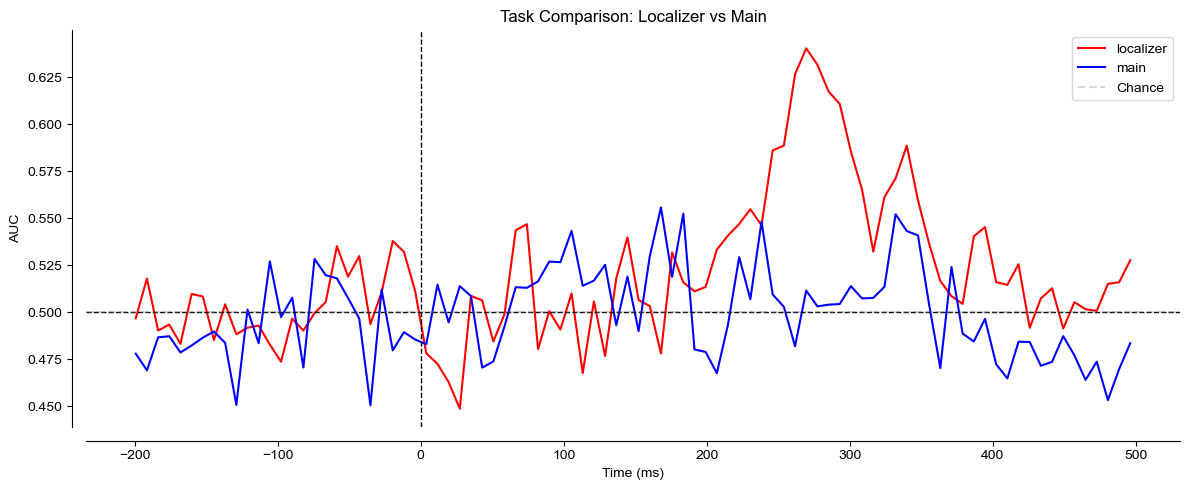


Results:
  • Localizer peak AUC: 0.640
  • Main task peak AUC: 0.556
  • Difference: 0.085


In [8]:
# Visualize comparison
fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    output_combined,
    colors=['red', 'blue'],  # localizer, main
    stats=False              # Single subject -- no group-level test to run
)
plt.title('Task Comparison: Localizer vs Main')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
plt.legend()
plt.tight_layout()
display(fig)
plt.close()

# Results
peak_auc_localizer = output_combined['localizer']['dec_scores'].max()
peak_auc_main = output_combined['main']['dec_scores'].max()
print(f"\nResults:")
print(f"  • Localizer peak AUC: {peak_auc_localizer:.3f}")
print(f"  • Main task peak AUC: {peak_auc_main:.3f}")
print(f"  • Difference: {peak_auc_localizer - peak_auc_main:.3f}")

---

## Section 4: Trial Averaging Trade-Off

**Research Question**: Does averaging trials together before decoding improve performance, and at what cost?

**Approach**: Run the same localizer decoding with increasing amounts of trial averaging (1, 2, 4, 6 trials averaged per training sample) and compare the resulting AUC timecourses.

Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1646 trials after specifying excl_factor


Applying baseline correction (mode: mean)


downsampling data



You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

Fold 2 out of 10 folds in run 1

...

Fold 7 out of 10 folds in run 1

Fold 8 out of 10 folds in run 1

Fold 9 out of 10 folds in run 1

Fold 10 out of 10 folds in run 1

Times converted from seconds to milliseconds


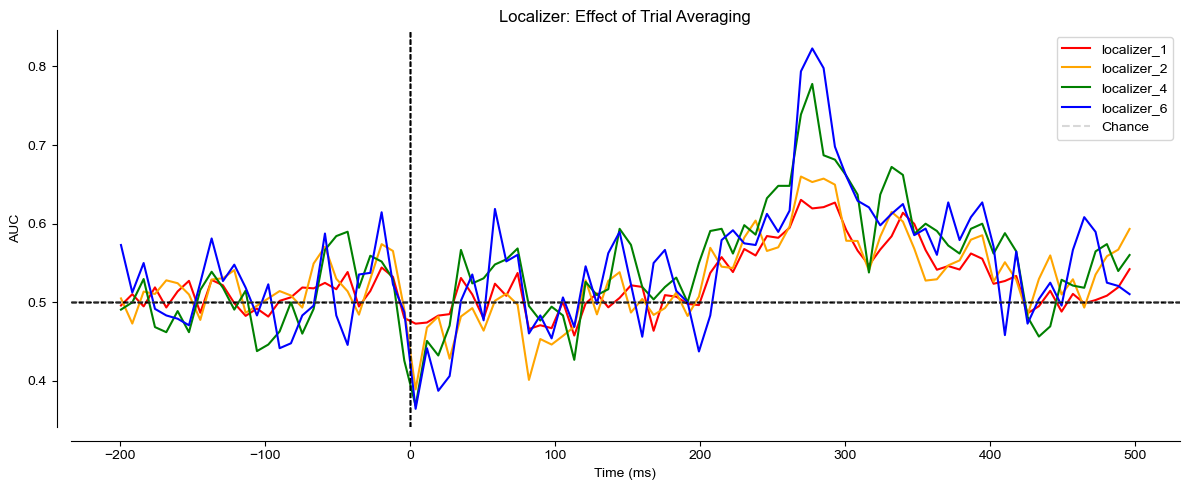

✓ Trial averaging analysis complete


In [9]:
# Test effect of trial averaging on localizer decoding
plt.close()
fig = plt.figure(figsize=(12, 5))

trial_avgs = [1, 2, 4, 6]
colors = ['red', 'orange', 'green', 'blue']

# Initialize once, will update avg_trials in loop
bdm_avg = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',    # Decode image identity
    baseline=(-0.2, 0),      # Baseline correction: -200 to 0 ms
    nr_folds=10,             # 10-fold cross-validation
    elec_oi='all',           # Use all electrodes
    data_type='broadband',   # Time domain (not TF)
    downsample=128,          # Downsample to 128 Hz (reduce computational load)
    avg_trials=1             # Initial value; overwritten per iteration below
)

for i, tr_avg in enumerate(trial_avgs):
    bdm_avg.avg_trials = tr_avg  # Update trial averaging
    
    output, _ = bdm_avg.classify(
        cnds=dict(block_type=['localizer']),  # Select localizer trials
        window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
        labels_oi='all',                      # Use all distractor images
        GAT=False,                            # Standard within-time decoding
        excl_factor=dict(img_loc=[8])         # Exclude trials where image not shown
    )
    
    # Rename key to track trial averaging
    output[f'localizer_{tr_avg}'] = output.pop('localizer')
    
    # Overlay each trial-averaging condition on the same axes
    plot_bdm_timecourse(
        output,
        colors=[colors[i]],  # This iteration's trial-averaging condition
        stats=False          # Single subject -- no group-level test to run
    )

plt.title('Localizer: Effect of Trial Averaging')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
plt.legend()
plt.tight_layout()
display(fig)
plt.close()

print("✓ Trial averaging analysis complete")

### Interpretation

**Benefits of trial averaging:**
- Reduces noise from single-trial variability
- Typically increases peak AUC (smoother signal)
- More stable temporal dynamics

**Costs of trial averaging:**
- Reduced sample size for cross-validation training
- Reduced sample size per fold, especially at high `avg_trials`, can increase overfitting risk -- though averaging also reduces single-trial noise, which partially offsets this


---

## Section 5: Cross-Task Decoding

**Research Question**: Does the neural representation of distractor image identity learned in the **localizer** (where it's task-relevant) generalize to the **main task** (where it's task-irrelevant)?

We'll train a decoder on localizer trials and test it on main task trials (without retraining), using the `cnds` cross-condition syntax.

In [10]:
# Reuse bdm_localizer: classify() copies self.epochs/self.df internally on
# every call, so the same instance can run any number of analyses safely

# Cross-task decoding: Train on localizer, test on main
# Format: {column: [[train_conditions], [test_conditions]]}
output_cross, _ = bdm_localizer.classify(
    cnds=dict(block_type=[['localizer'], ['main']]),  # Train on localizer, test on main
    window_oi=(-0.2, 0.5),                            # Time window: -200 to 500 ms
    labels_oi='all',                                  # Use all distractor images
    GAT=False,                                        # Standard within-time decoding
    excl_factor=dict(img_loc=[8])                     # Exclude trials where image not shown
)

print("✓ Cross-task decoding complete")

Dropped 805 trials after specifying excl_factor


Applying baseline correction (mode: mean)


downsampling data



The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 1 folds in run 1

✓ Cross-task decoding complete


Times converted from seconds to milliseconds


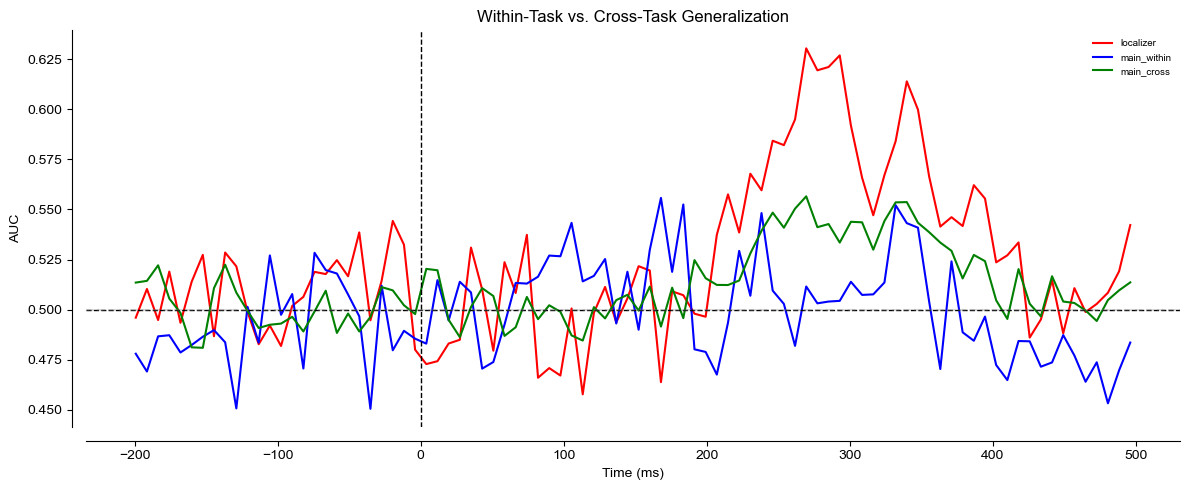

✓ Cross-task comparison complete


In [11]:
# Compare within-task vs. cross-task decoding
# Combine outputs for plotting
combined_cross = {
    'localizer': output_localizer['localizer'],
    'main_within': output_combined['main'],
    'main_cross': output_cross['localizer_main'],
    'info': output_localizer['info']
}

fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    combined_cross,
    colors=['red', 'blue', 'green'],  # localizer, main (within-task), main (cross-task)
    stats=False                       # Single subject -- no group-level test to run
)
plt.title('Within-Task vs. Cross-Task Generalization')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Chance')
plt.tight_layout()
display(fig)
plt.close()

print("✓ Cross-task comparison complete")

---

## Section 6: Summary and Next Steps

You've now completed a full decoding analysis pipeline:

1. ✅ **Localizer decoding**: Simple task, strong signal, clear timing
2. ✅ **Main task decoding**: Complex task, more realistic, weaker signal
3. ✅ **Trial averaging optimization**: Balance SNR vs. sample size
4. ✅ **Cross-task generalization**: Test whether representations are task-invariant

### Next Steps
- See `06_bdm_advanced.ipynb` for:
  - Generalization Across Time (GAT)
  - Time-frequency domain decoding
  - Classifier comparisons
  - Statistical testing
  - Cross-subject generalization